# Student Depression Prediction using Machine Learning
**Student:** Atheer  
**Dataset:** [Student Depression & Lifestyle (100k Data)](https://www.kaggle.com/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data)  
**Goal:** develop a machine learning model that predicts whether a student is at risk of depression based on demographic, academic, and lifestyle factors.



## 1.Data Loading & First Look
Load the dataset and display its shape, column types, and the first rows.

In [1]:
# Download the library for Data Manipulation and Visualization
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import kagglehub

# Download latest version from kagglehub
path = kagglehub.dataset_download("aldinwhyudii/student-depression-and-lifestyle-100k-data")

print("Path to dataset files:", path)

100%|██████████| 1.25M/1.25M [00:01<00:00, 1.26MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data/versions/1


In [3]:
import os
# find where the dataset csv file in colab
csv_path = os.path.join(path, "student_lifestyle_100k.csv")
df = pd.read_csv(csv_path)

# show the first five rows
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [4]:
# show the last five rows
df.tail()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
99995,100996,24,Female,Medical,2.02,7.0,0.6,1.4,66,4,False
99996,100997,24,Male,Arts,2.33,5.0,3.6,5.2,103,3,False
99997,100998,24,Female,Engineering,2.23,6.5,5.8,4.1,61,5,False
99998,100999,19,Male,Engineering,3.61,6.1,4.8,4.9,116,4,False
99999,101000,24,Female,Medical,2.10,7.9,3.5,4.0,79,4,False


In [5]:
# show the number of rows and columns
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist() }")

Dataset shape: (100000, 11)
Columns: ['Student_ID', 'Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression']


In [6]:
# show dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [7]:
# show data types
df.dtypes

,0
Student_ID,int64
Age,int64
Gender,object
Department,object
CGPA,float64
Sleep_Duration,float64
Study_Hours,float64
Social_Media_Hours,float64
Physical_Activity,int64
Stress_Level,int64


The First Look in the dataset tell us, the dataset contains 100000 samples and 11 features, it is a large dataset, make it good for machine  learning analysis

The dataset includes both numerical and categorical features.

Numerical variables are (Age, CGPA, Sleep Duration, Study Hours, Social Media Hours, Physical Activity, Stress Level)

The Categorical variables are (Gender, Department)

our Target variable is Depression, is a binary feature indicating whether a student is at risk of Depression



## 2. Exploratory Data Analysis (EDA)
Summary statistics, distributions of key features, and at least three meaningful visualizations (e.g., histograms, correlation heatmap, boxplots).

In [8]:
# Show summary of all columns in the dataset (of both Numerical variables and Categorical variable)
df.describe(include="all")

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
count,100000.000000,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Male,Science,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,50120,20071,NaN,NaN,NaN,NaN,NaN,NaN,89938
mean,51000.500000,21.009010,NaN,NaN,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660,NaN
std,28867.657797,2.000382,NaN,NaN,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151,NaN
min,1001.000000,18.000000,NaN,NaN,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,NaN
25%,26000.750000,19.000000,NaN,NaN,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,NaN
50%,51000.500000,21.000000,NaN,NaN,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,NaN
75%,76000.250000,23.000000,NaN,NaN,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,NaN


In [9]:
# show Summary for Numerical variables
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [10]:
# show summary for Categorical variables
df.describe(include='object')

,Gender,Department
count,100000,100000
unique,2,5
top,Male,Science
freq,50120,20071


In [11]:
# Count the number of unique values in each columns
df.nunique()

,0
Student_ID,100000
Age,7
Gender,2
Department,5
CGPA,237
Sleep_Duration,91
Study_Hours,126
Social_Media_Hours,97
Physical_Activity,150
Stress_Level,9


In [12]:
# Check for the missing values
missing = df.isnull().sum()
missing_pct = ( df.isnull().sum() / len(df) * 100).round(2)
missing_table = pd.DataFrame({ "Missing Count": missing, "Missing Percentage": missing_pct})
missing_table.sort_values( by="Missing Count", ascending=False)

,Missing Count,Missing Percentage
Student_ID,0,0.0
Age,0,0.0
Gender,0,0.0
Department,0,0.0
CGPA,0,0.0
Sleep_Duration,0,0.0
Study_Hours,0,0.0
Social_Media_Hours,0,0.0
Physical_Activity,0,0.0
Stress_Level,0,0.0


In [13]:
# Check for duplicate rows in all the dataset
print("Duplicate rows:", df.duplicated().sum())

# and Check for duplicate rows in Student_ID
print("Duplicate in Student_IDs:", df["Student_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate in Student_IDs: 0


The exploratory data analysis shows to us that there are No missing values or duplicate records  meaning the dataset is consistent and need to just some data cleaning steps before preprocessing(for use it in models training)

The Student_ID column have an unique identifiers for each student. It does not provide predictive information about Depression, so it will be removed before training the models

In [14]:
# Count the target classes
df["Depression"].value_counts()

,count
Depression,
False,89938
True,10062


In [15]:
# show the percentage % of the target classes (Depression)
(df["Depression"].value_counts(normalize=True) * 100).round(2)

,proportion
Depression,
False,89.94
True,10.06


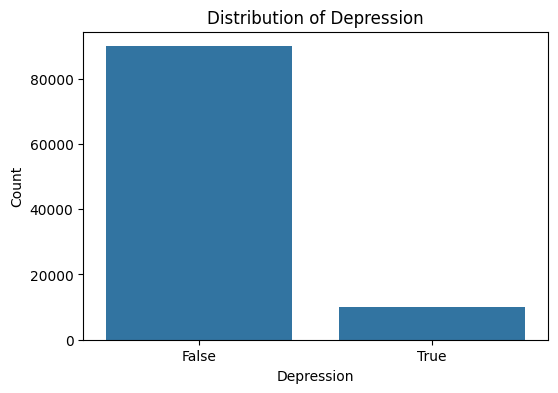

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Depression")
plt.title("Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Count")
plt.show()

The distribution show to us that the Target variable (Depression) is imbalanced, with 89.94 % of students labeled as (not Depression) and 10.06% labeled as (Depression)

Because the dataset is imbalanced, accuracy alone will not provide well evaluation of models performance.
so i will use other metrics, such as Precision, Recall, and F1-score to evaluate the models ability to identify students at risk of depression.


In [17]:
# Select what are the Numerical variable(features)
numerical_features = [ "Age", "CGPA", "Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Physical_Activity", "Stress_Level" ]

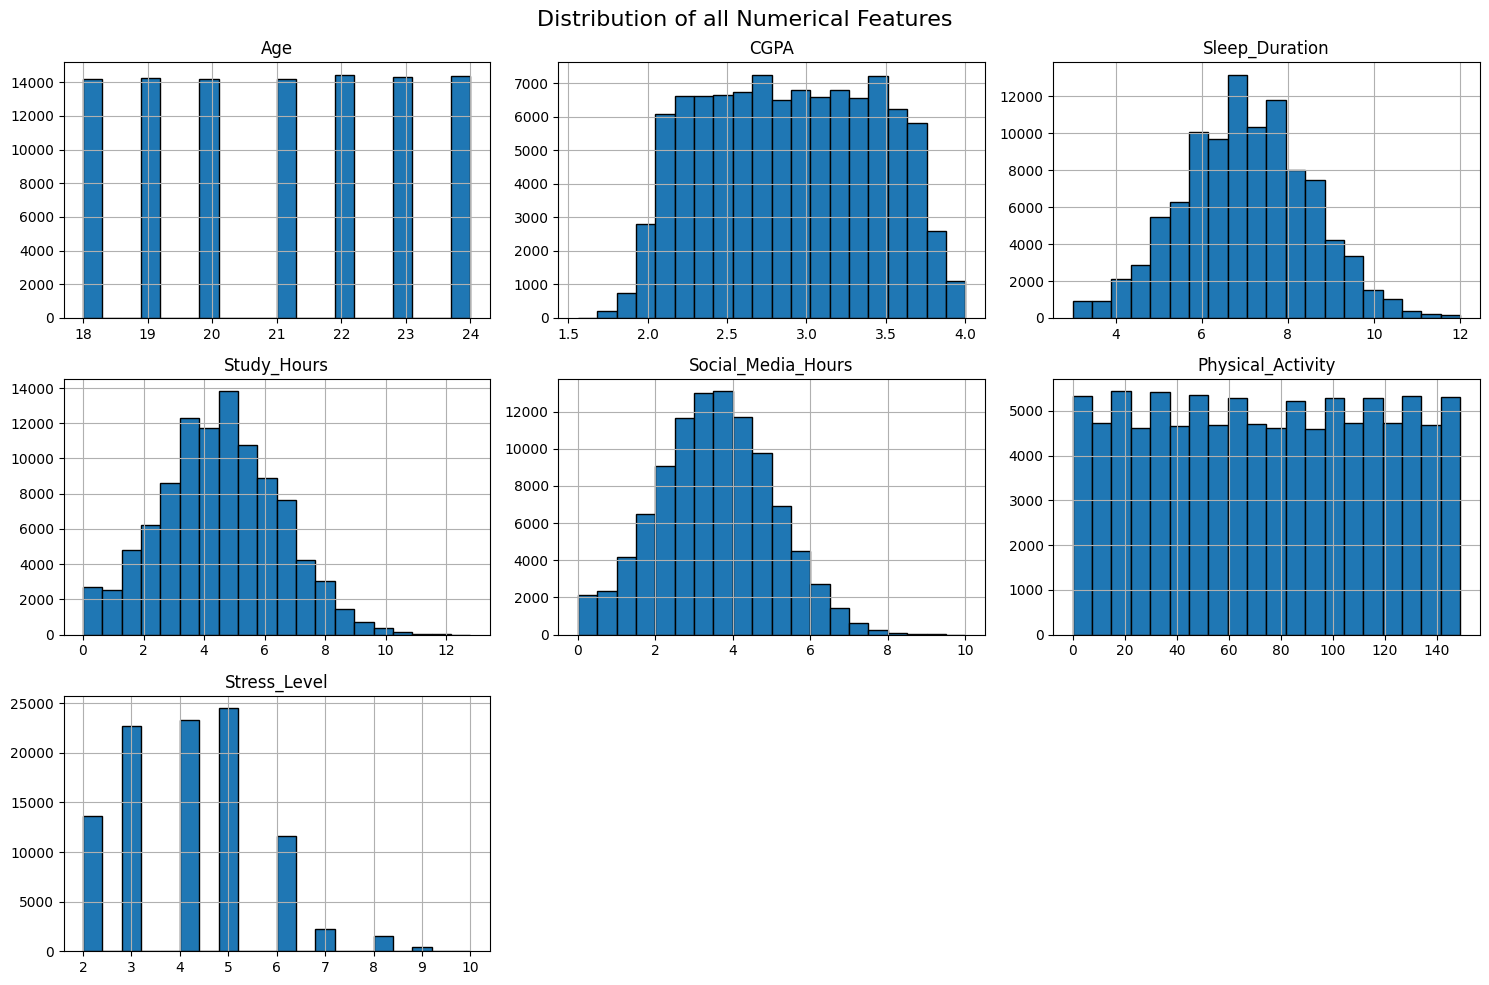

In [18]:
#edgecolor="black" to show each columns clearly
df[numerical_features].hist(figsize=(15, 10), bins=20, edgecolor="black")

plt.suptitle("Distribution of all Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

(Sleep Duration) is a normal distribution with around 7 hours in the center,  (Study Hours) and (Social Media Hours) are mostly around their middle values with slight skewness to right.

The (Age) and (Physical Activity) are distributed evenly across their ranges, meaning the dataset includes a balanced representation of these values. (CGPA) is also well distributed, with most students having values between 2.0 and 3.8.


The (Stress Level) is discrete, with students reporting stress levels between 3 and 5.

In [19]:
# Select what are the Categorical variable(features)
categorical_features = [ "Gender", "Department"]

In [20]:
# Count the Gender distribution
df["Gender"].value_counts()

,count
Gender,
Male,50120
Female,49880


In [21]:
# show the percentage % of the Gender class
(df["Gender"].value_counts(normalize=True) * 100).round(2)

,proportion
Gender,
Male,50.12
Female,49.88


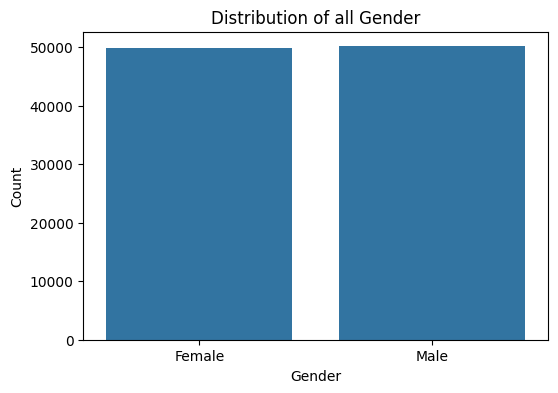

In [22]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="Gender")
plt.title("Distribution of all Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [23]:
# Count Department distribution
df["Department"].value_counts()

,count
Department,
Science,20071
Engineering,20057
Arts,19998
Medical,19964
Business,19910


In [24]:
# show the percentage % of the Department class
(df["Department"].value_counts(normalize=True) * 100).round(2)

,proportion
Department,
Science,20.07
Engineering,20.06
Arts,20.00
Medical,19.96
Business,19.91


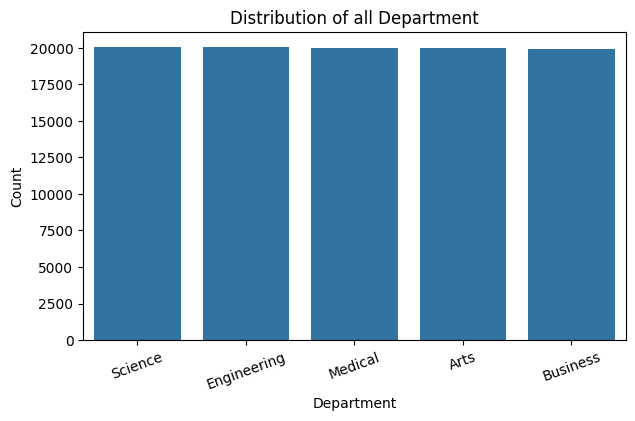

In [25]:
plt.figure(figsize=(7,4))
ax = sns.countplot(data=df, x="Department")
plt.title("Distribution of all Department")
plt.xlabel("Department")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

The categorical features are well balanced.
The (Gender) is nearly equal numbers of male and female students, meaning neither gender is more common the dataset.


the (Department) is evenly distributed for all the five academic departments (Science, Engineering, Medical, Arts, and Business).

This balanced distribution reduces the probability of bias for any one of the departments during model training.



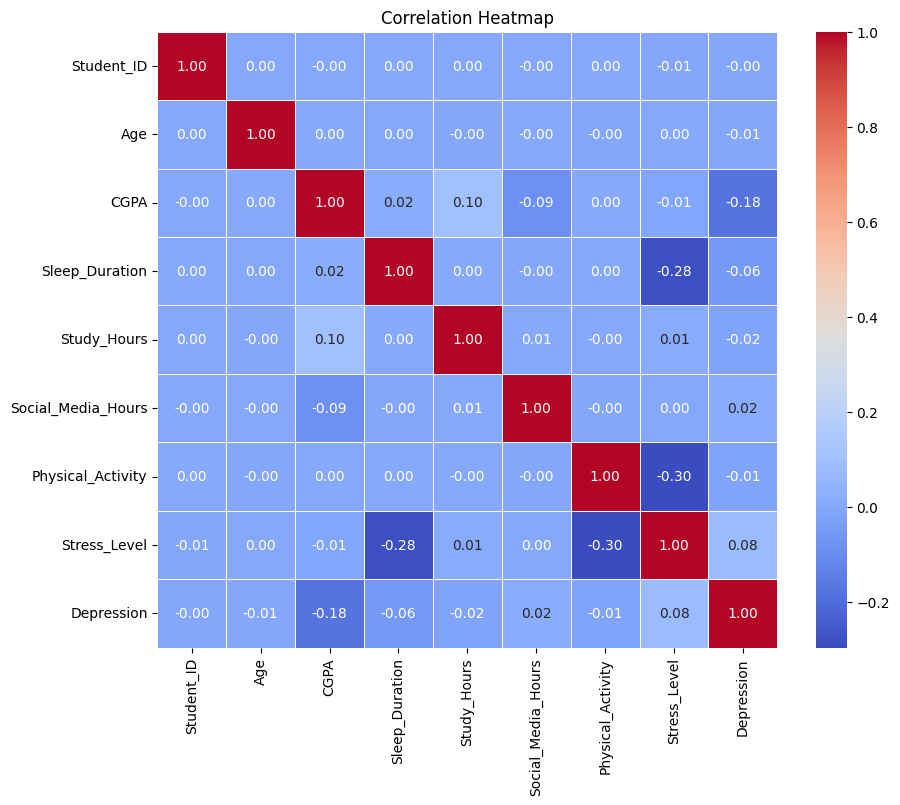

In [26]:
# Create a copy of data to see correlation analysis before start clearn it, to know the relationships
corr_df = df.copy()

# Convert the target variable to integers to make it easy to read
corr_df["Depression"] = corr_df["Depression"].astype(int)

correlation_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap( correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows u, most features have a weak relationship with Depression and with each other. This means there are no features strongly affect our target(Depression)

But there are strong relationships between Physical Activity and Stress Level, and between Sleep Duration and Stress Level
(that means the Students who sleep well (for example: 6 to 8) or physically active(for example: doing a workout) have lower stress levels)

Student_ID has no relationship with other features, so it will be removed from the dataset.(in data clear section)





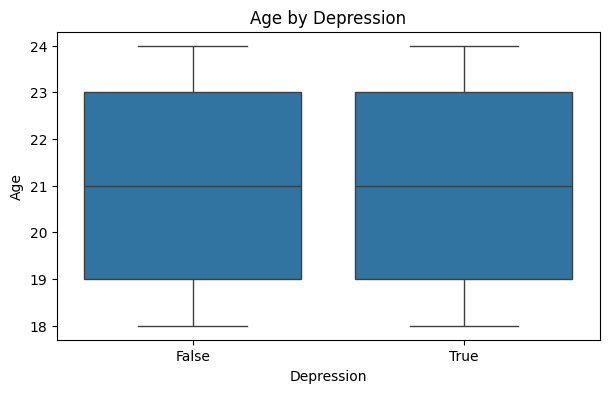

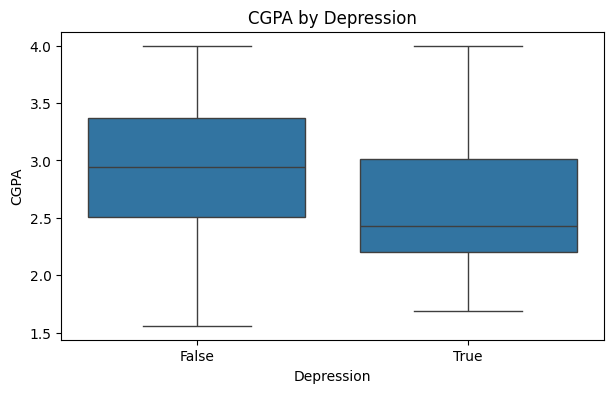

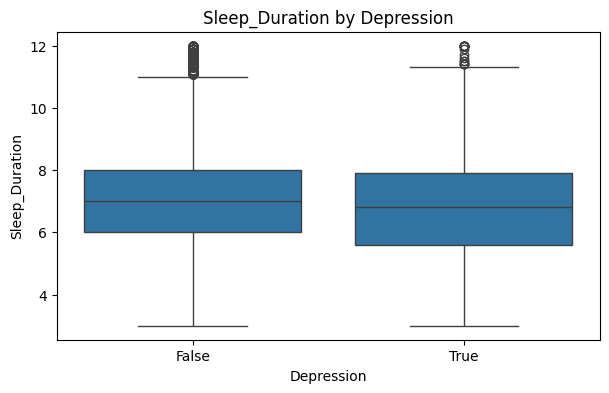

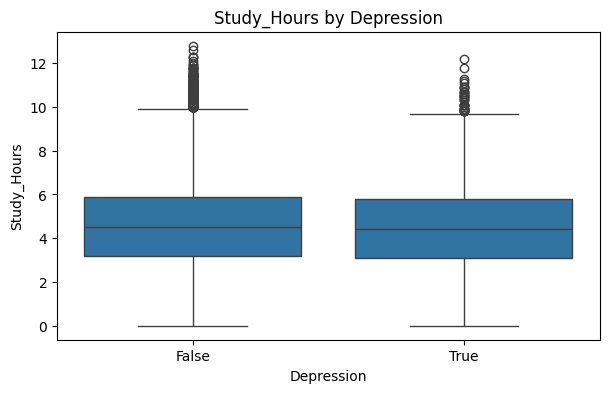

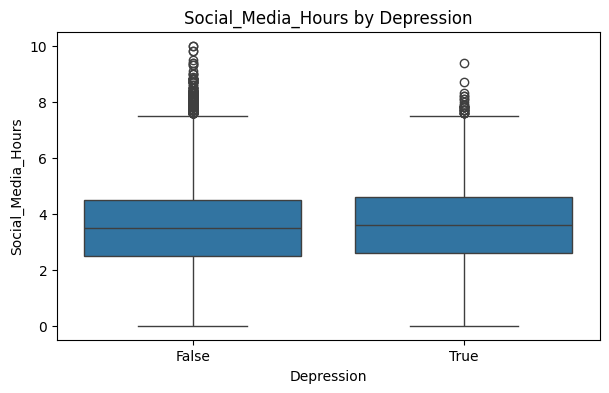

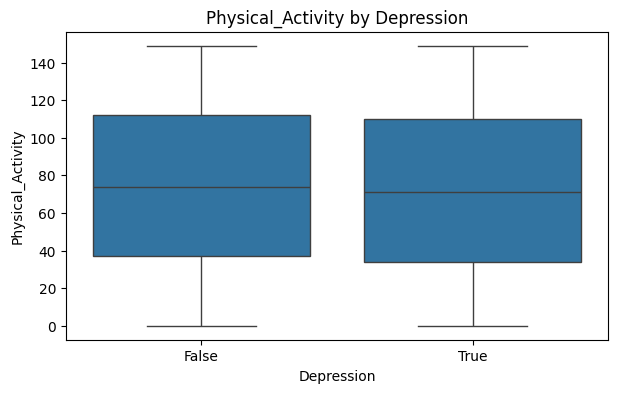

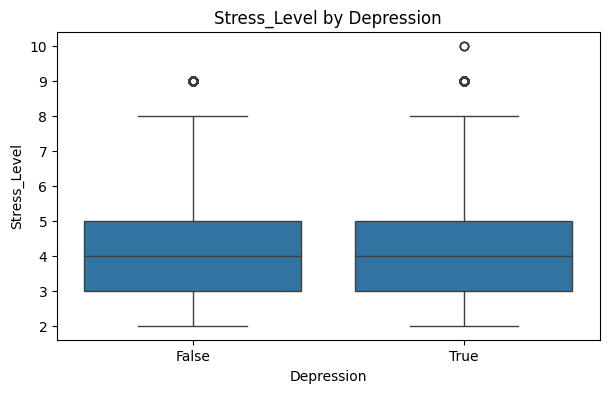

In [27]:
# Create boxplots for توزيع بيانات في numerical featuresو Depression قسم البيانات حسب .
#Depression = 0 او Depression = 1
for col in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Depression", y=col)
    plt.title(f"{col} by Depression")
    plt.show()

there are some outliers in "Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Stress_Level

These values may represent a real student activities, so I do not remove them.  they will be handled using the IQR capping method




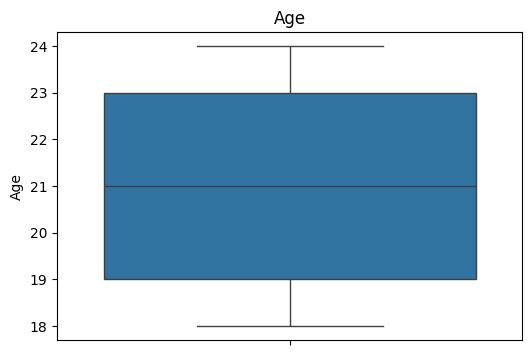

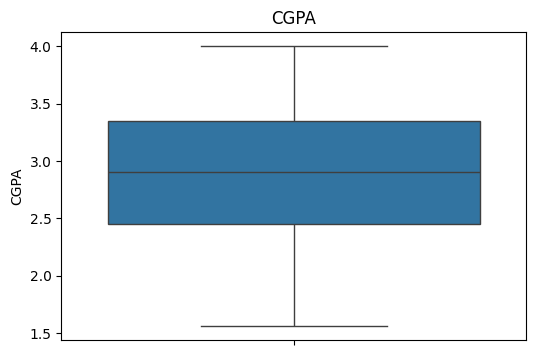

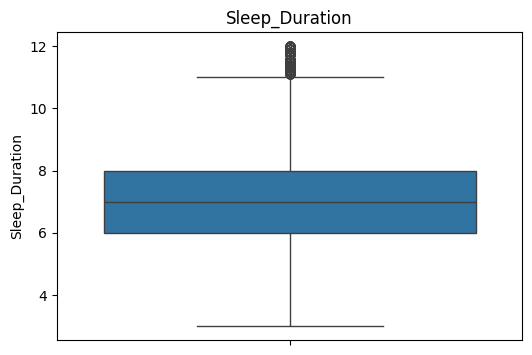

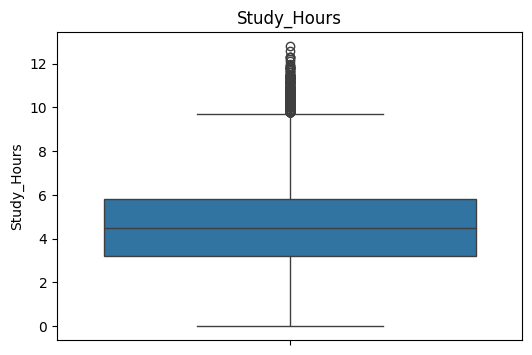

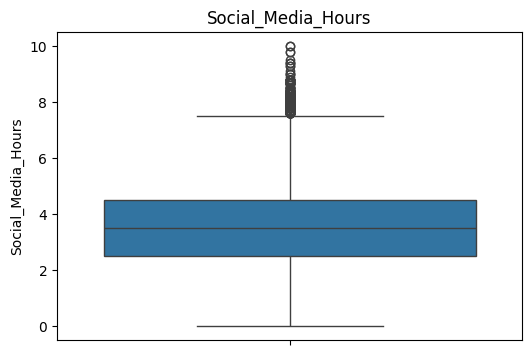

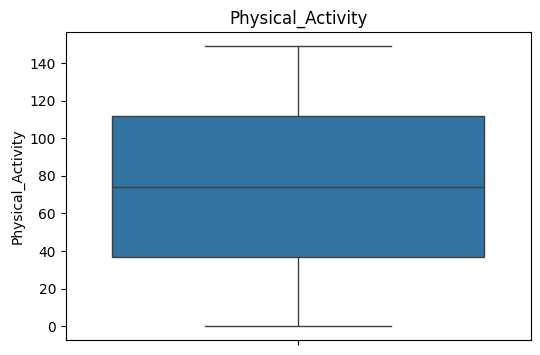

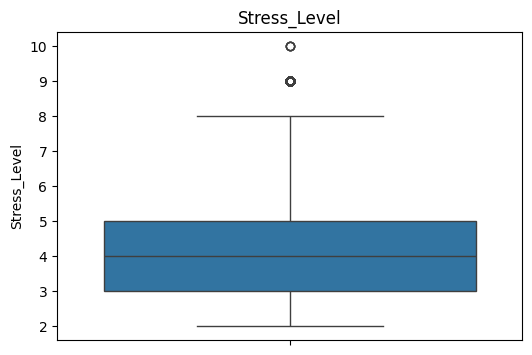

In [28]:
# boxplot for معرفة توزيع the numbers outliers in all numerical features
for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

In [29]:
# count the number of outliers numerical features before Outlier Handling
for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Age: 0 outliers
CGPA: 0 outliers
Sleep_Duration: 369 outliers
Study_Hours: 432 outliers
Social_Media_Hours: 328 outliers
Physical_Activity: 0 outliers
Stress_Level: 478 outliers


the number of outliers in numerical features are:
Age: 0 outliers
CGPA: 0 outliers
Sleep_Duration: 369 outliers
Study_Hours: 432 outliers
Social_Media_Hours: 328 outliers
Physical_Activity: 0 outliers
Stress_Level: 478 outliers

they will be handled later (in data cleaning section) using the IQR capping method.




## 3. Data Cleaning
Handle missing values, duplicates, and outliers. Justify the strategy you chose (e.g., why mean vs. median imputation).

In [30]:
# Create a copy for cleaning the data لتجنب لخبطت البيانات
df_clean = df.copy()

# Remove Student_ID column
#it does not help in predicting depression, so I removed it.
df_clean.drop(columns="Student_ID", inplace=True)

# show the first rows after remove the Student_ID column
print("Dataset shape:", df_clean.shape)
df_clean.head()

Dataset shape: (100000, 10)


,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [31]:
df_clean.dtypes

,0
Age,int64
Gender,object
Department,object
CGPA,float64
Sleep_Duration,float64
Study_Hours,float64
Social_Media_Hours,float64
Physical_Activity,int64
Stress_Level,int64
Depression,bool


In [32]:
# Outlier Handling for "Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Stress_Level هنا معالجة Outlier
for col in ["Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Stress_Level"]:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

In [33]:
# count the number of outliers numerical features after Outlier Handling هنا حسبنا Outlier مرة اخرى للتاكيد
for col in numerical_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Age: 0 outliers
CGPA: 0 outliers
Sleep_Duration: 0 outliers
Study_Hours: 0 outliers
Social_Media_Hours: 0 outliers
Physical_Activity: 0 outliers
Stress_Level: 0 outliers


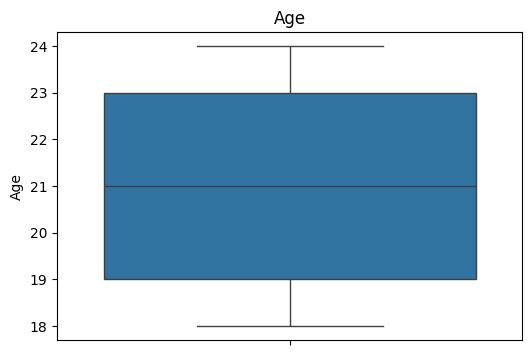

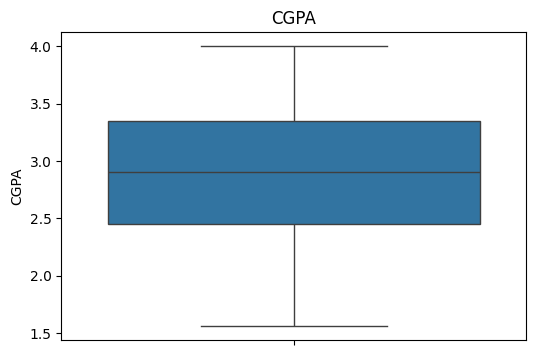

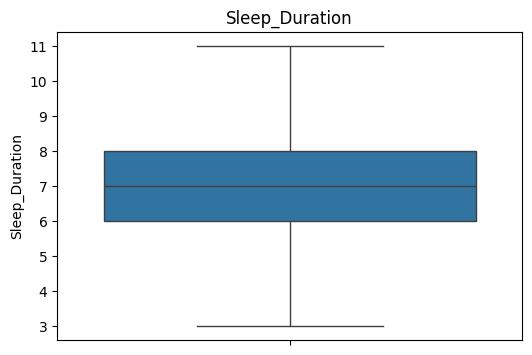

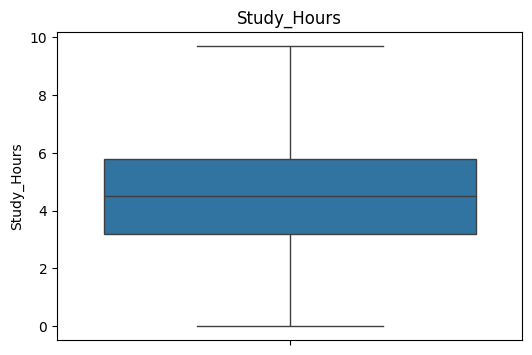

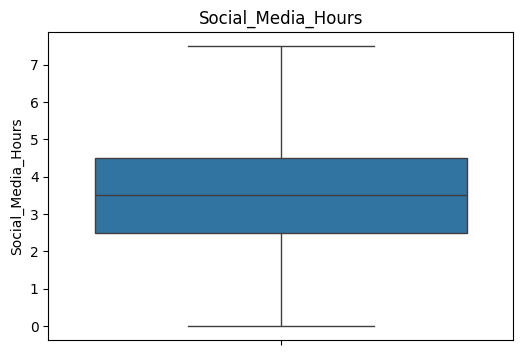

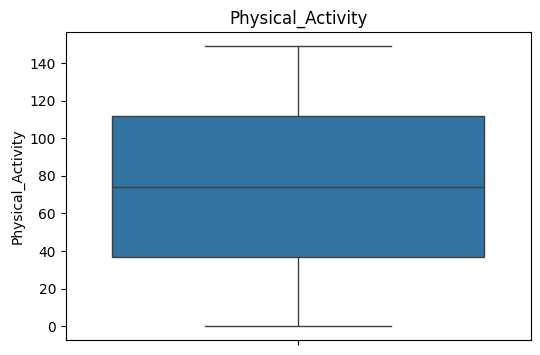

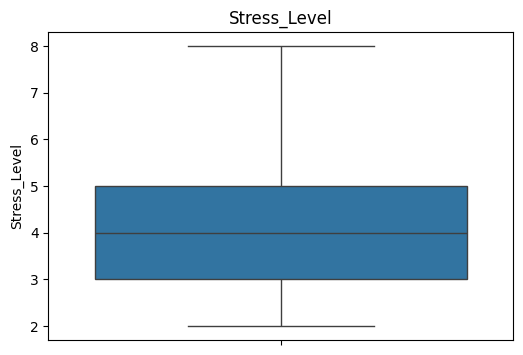

In [34]:
# boxplot for outliers in numerical features after Outlier Handling توزيع البيانات بعد معالجة Outlier
for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df_clean[col])
    plt.title(col)
    plt.show()

In [35]:
#show the dataset after Outlier Handling
df_clean.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


## 4. Preprocessing
Encode categorical features where needed, then apply feature scaling. Explain why scaling is required for your chosen models.

In [36]:
# Convert target to integer حتى تقدر يتعامل معها المودل
df_clean["Depression"] = df_clean["Depression"].astype(int)

In [37]:
# Check the values in categorical columns
print(df_clean["Gender"].unique())
print(df_clean["Department"].unique())

# Convert Gender to 0 for male and 1 for female
df_clean["Gender"] = df_clean["Gender"].map({"Male": 0, "Female": 1})

# Convert Department to number using one-hot encoding
df_clean = pd.get_dummies(df_clean, columns=["Department"], drop_first=True, dtype=int)

# show the data after change categorical columns to numbers
df_clean.head()

['Female' 'Male']
['Science' 'Engineering' 'Medical' 'Arts' 'Business']


,Age,Gender,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,1,3.50,7.3,3.3,3.4,114,5,0,0,0,0,1
1,20,0,2.72,5.5,7.2,6.0,142,2,0,0,1,0,0
2,20,0,3.01,5.4,2.3,1.8,137,3,0,0,0,1,0
3,21,0,3.63,8.1,2.0,4.6,130,3,0,0,1,0,0
4,19,0,3.14,6.8,2.6,4.3,4,6,0,0,0,0,0


In [38]:
#dataset types after Convert Categorical features to numbers
df_clean.dtypes

,0
Age,int64
Gender,int64
CGPA,float64
Sleep_Duration,float64
Study_Hours,float64
Social_Media_Hours,float64
Physical_Activity,int64
Stress_Level,int64
Depression,int64
Department_Business,int64


##Feature Engineering

In [39]:
# Create Sleep Deficit feature from 8 hours of sleep (-) sleep hours.
df_clean["Sleep_Deficit"] = (8 - df_clean["Sleep_Duration"]).clip(lower=0)

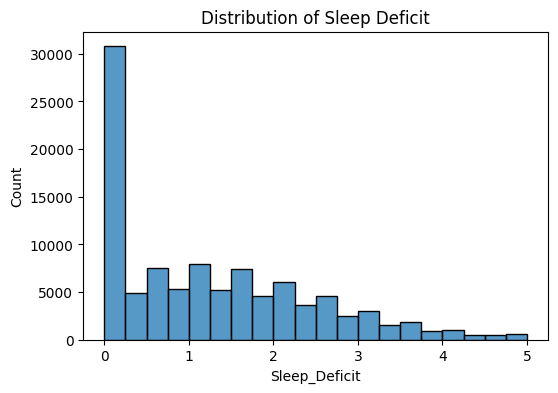

In [40]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean["Sleep_Deficit"], bins=20)
plt.title("Distribution of Sleep Deficit")
plt.show()

(Sleep_Deficit) measures how many hours of sleep are missing from 8 hours of sleep.


In [41]:
# Create Total Daily Load feature from time of spent on study and SMS
df_clean["Total_Daily_Load"] = (
    df_clean["Study_Hours"] + df_clean["Social_Media_Hours"]
)

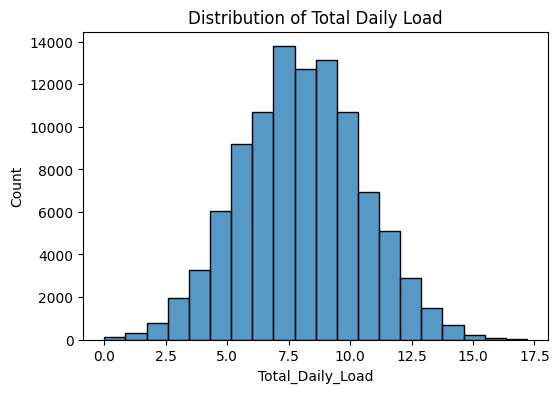

In [42]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean["Total_Daily_Load"], bins=20)
plt.title("Distribution of Total Daily Load")
plt.show()

(Total_Daily_Load) show the total time of spending on study and social media


##Train-Test Split

In [43]:
# فصل features عن target variable
X = df_clean.drop(columns ="Depression")
y = df_clean["Depression"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100000, 14)
Target shape: (100000,)


In [44]:
from sklearn.model_selection import train_test_split

# Split the dataset to avoid dataleak
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (80000, 14)
Testing set: (20000, 14)


In [45]:
from sklearn.preprocessing import StandardScaler

numerical_columns = [ "Age", "CGPA", "Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Physical_Activity", "Stress_Level", "Sleep_Deficit", "Total_Daily_Load"]

scaler = StandardScaler()

# Scale the training data but i create a copy to keep the data unchanged after scale
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()


X_train_scaled[numerical_columns] = scaler.fit_transform( X_train[numerical_columns])
X_test_scaled[numerical_columns] = scaler.transform( X_test[numerical_columns])


# Show the first rows after Scale
X_train_scaled.head()

,Age,Gender,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Department_Business,Department_Engineering,Department_Medical,Department_Science,Sleep_Deficit,Total_Daily_Load
23196,0.992346,0,-0.335515,-0.868536,0.759890,0.406135,1.539015,-1.507633,0,0,1,0,0.906855,0.849442
25929,-1.504782,0,0.773208,0.873926,1.319765,-0.673901,-1.506493,0.621304,0,1,0,0,-1.039088,0.646676
78344,0.992346,0,0.209451,0.069713,-1.530508,-0.471394,-1.321916,1.330949,0,0,0,0,-0.277632,-1.502645
61281,0.992346,1,-1.406654,-0.131341,0.250912,0.001121,0.154693,-0.797988,0,0,1,0,-0.023813,0.200590
94316,-0.505931,1,0.585289,-2.476961,0.352708,0.946152,1.446727,0.621304,0,0,0,0,2.937403,0.849442


In [46]:
# show the target column  عشان نشوف اذا هي متوازن ام ولا
print(y.value_counts())
# the dataset imbalanced نحتاج نوازنها قبل ترتيب المودل

Depression
0    89938
1    10062
Name: count, dtype: int64


## 5. Dimensionality Reduction (PCA)
Apply PCA, report how much variance the components explain, and comment on whether it helped.

In [47]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_scaled)
ratios = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(ratios.round(4))

print("Total Explained Variance Ratio:")
print(ratios.sum())

Explained Variance Ratio:
[0.2146 0.2028 0.1211 0.1137 0.1011 0.0878 0.0637 0.0253 0.0203 0.0202
 0.0202 0.0051 0.004  0.    ]
Total Explained Variance Ratio:
0.9999999999999999


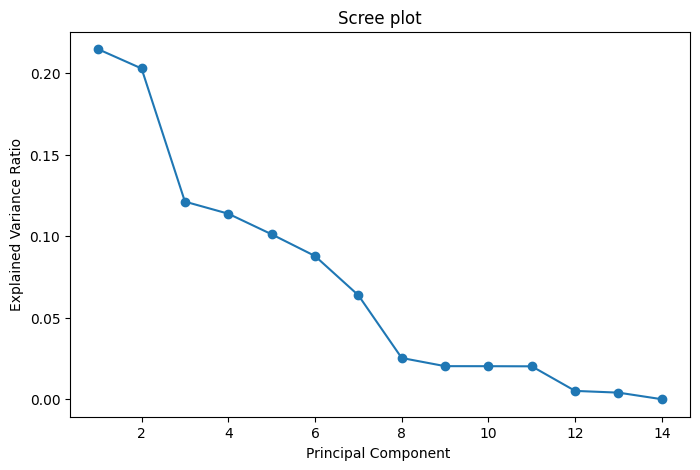

In [48]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(ratios) + 1), ratios, "o-")
plt.xlabel("Principal Component ")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree plot")
plt.show()

In [49]:
total = 0
count = 0
for r in ratios:
    total = total + r
    count = count + 1
    if total >= 0.95:
        break

print(count, "components reach 95% of the variance")

9 components reach 95% of the variance


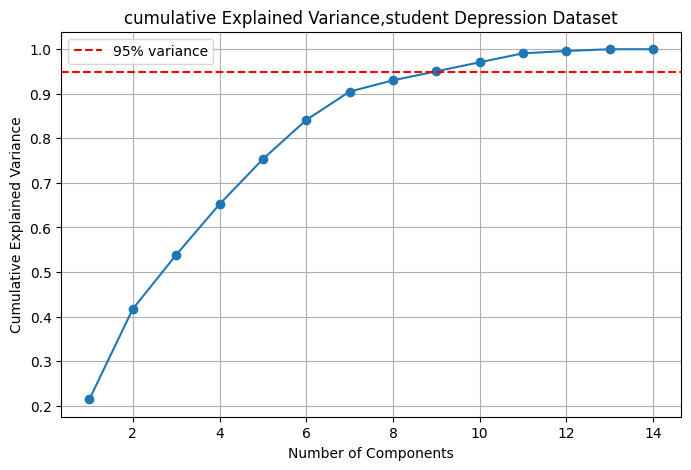

In [50]:
cum_var = np.cumsum(ratios)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("cumulative Explained Variance,student Depression Dataset")
plt.legend()
plt.grid(True)
plt.show()


In [51]:
pca = PCA(n_components=count)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])

Original number of features: 14
Number of PCA components: 9


The dataset before PCA contained 14 features. After applying PCA, it was reduced to 9 principal components while preserving about 95% of the dataset variance. meaning the most of important data features, still there even after applying PCA

## 6. Modeling
Split the data into training and testing sets, then train at least two different models suitable for your task.

In [52]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


# Model Selection and Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix



## Model 1 — Logistic Regression

with default parameter

In [53]:
#default parameter with pca
model_lr = LogisticRegression(random_state=42).fit(X_train_pca, y_train)
y_pred_lr = model_lr.predict(X_test_pca)

acc_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression with PCA")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")

print()

#default parameter without pca
model_lr_no_PCA = LogisticRegression(random_state=42).fit(X_train_scaled, y_train)
y_pred_lr_no_PCA = model_lr_no_PCA.predict(X_test_scaled)

acc_lr_no_PCA = accuracy_score(y_test, y_pred_lr_no_PCA)
precision_lr_no_PCA = precision_score(y_test, y_pred_lr_no_PCA)
recall_lr_no_PCA = recall_score(y_test, y_pred_lr_no_PCA)
f1_lr_no_PCA = f1_score(y_test, y_pred_lr_no_PCA)

print("Logistic Regression without PCA")
print(f"Accuracy : {acc_lr_no_PCA:.4f}")
print(f"Precision: {precision_lr_no_PCA:.4f}")
print(f"Recall   : {recall_lr_no_PCA:.4f}")
print(f"F1-score : {f1_lr_no_PCA:.4f}")

Logistic Regression with PCA
Accuracy : 0.8994
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

Logistic Regression without PCA
Accuracy : 0.8994
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


## Model 2 — Decision Tree

with default parameter

In [54]:
#default parameter with pca
model_dt = DecisionTreeClassifier(random_state=42).fit(X_train_pca, y_train)
y_pred_dt = model_dt.predict(X_test_pca)

acc_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)


print("Decision Tree with PCA")
print(f"Accuracy : {acc_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-score : {f1_dt:.4f}")

print()

#default parameter without pca
model_dt_no_PCA= DecisionTreeClassifier(random_state=42).fit(X_train_scaled, y_train)
y_pred_dt_no_PCA = model_dt_no_PCA.predict(X_test_scaled)

acc_dt_no_PCA = accuracy_score(y_test, y_pred_dt_no_PCA)
precision_dt_no_PCA = precision_score(y_test, y_pred_dt_no_PCA)
recall_dt_no_PCA = recall_score(y_test, y_pred_dt_no_PCA)
f1_dt_no_PCA = f1_score(y_test, y_pred_dt_no_PCA)


print("Decision Tree without PCA")

print(f"Accuracy : {acc_dt_no_PCA:.4f}")
print(f"Precision: {precision_dt_no_PCA:.4f}")
print(f"Recall   : {recall_dt_no_PCA:.4f}")
print(f"F1-score : {f1_dt_no_PCA:.4f}")


Decision Tree with PCA
Accuracy : 0.8216
Precision: 0.1689
Recall   : 0.1973
F1-score : 0.1820

Decision Tree without PCA
Accuracy : 0.8162
Precision: 0.1510
Recall   : 0.1789
F1-score : 0.1638


## Model 3 — Random Forest
with default parameter

In [55]:
#default parameter with pca
model_rf = RandomForestClassifier(random_state=42).fit(X_train_pca, y_train)
y_pred_rf = model_rf.predict(X_test_pca)

acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest with PCA")

print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

print()

#default parameter without pca
model_rf_no_PCA = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)
y_pred_rf_no_PCA = model_rf_no_PCA.predict(X_test_scaled)

acc_rf_no_PCA = accuracy_score(y_test, y_pred_rf_no_PCA)
precision_rf_no_PCA = precision_score(y_test, y_pred_rf_no_PCA)
recall_rf_no_PCA = recall_score(y_test, y_pred_rf_no_PCA)
f1_rf_no_PCA = f1_score(y_test, y_pred_rf_no_PCA)

print("Random Forest without PCA")

print(f"Accuracy : {acc_rf_no_PCA:.4f}")
print(f"Precision: {precision_rf_no_PCA:.4f}")
print(f"Recall   : {recall_rf_no_PCA:.4f}")
print(f"F1-score : {f1_rf_no_PCA:.4f}")

Random Forest with PCA
Accuracy : 0.8994
Precision: 0.5062
Recall   : 0.0204
F1-score : 0.0392

Random Forest without PCA
Accuracy : 0.8992
Precision: 0.4824
Recall   : 0.0204
F1-score : 0.0391


## Model 4 — K-Nearest Neighbors (KNN)
with default parameter

In [56]:
#default parameter with pca
model_knn = KNeighborsClassifier().fit(X_train_pca, y_train)

y_pred_knn = model_knn.predict(X_test_pca)

acc_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("K-Nearest Neighbors (KNN) with PCA")

print(f"Accuracy : {acc_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1-score : {f1_knn:.4f}")

print()

#default parameter without pca
model_knn_no_PCA = KNeighborsClassifier().fit(X_train_scaled, y_train)
y_pred_knn_no_PCA = model_knn_no_PCA.predict(X_test_scaled)

acc_knn_no_PCA = accuracy_score(y_test, y_pred_knn_no_PCA)
precision_knn_no_PCA = precision_score(y_test, y_pred_knn_no_PCA)
recall_knn_no_PCA = recall_score(y_test, y_pred_knn_no_PCA)
f1_knn_no_PCA = f1_score(y_test, y_pred_knn_no_PCA)

print("K-Nearest Neighbors (KNN) without PCA")

print(f"Accuracy : {acc_knn_no_PCA:.4f}")
print(f"Precision: {precision_knn_no_PCA:.4f}")
print(f"Recall   : {recall_knn_no_PCA:.4f}")
print(f"F1-score : {f1_knn_no_PCA:.4f}")

K-Nearest Neighbors (KNN) with PCA
Accuracy : 0.8892
Precision: 0.2437
Recall   : 0.0482
F1-score : 0.0805

K-Nearest Neighbors (KNN) without PCA
Accuracy : 0.8914
Precision: 0.2846
Recall   : 0.0522
F1-score : 0.0882


## Model 5 — Support Vector Machine (SVM)
with default parameter

In [57]:
#default parameter with pca
model_svm = SVC(kernel="linear", random_state=42).fit(X_train_pca, y_train)

y_pred_svm = model_svm.predict(X_test_pca)

acc_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Support Vector Machine (SVM) with PCA")

print(f"Accuracy : {acc_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")

print()

#default parameter without pca
model_svm_no_PCA = SVC(kernel="linear", random_state=42).fit(X_train_scaled, y_train)
y_pred_svm_no_PCA = model_svm_no_PCA.predict(X_test_scaled)

acc_svm_no_PCA = accuracy_score(y_test, y_pred_svm_no_PCA)
precision_svm_no_PCA = precision_score(y_test, y_pred_svm_no_PCA)
recall_svm_no_PCA = recall_score(y_test, y_pred_svm_no_PCA)
f1_svm_no_PCA = f1_score(y_test, y_pred_svm_no_PCA)

print("Support Vector Machine (SVM) with PCA")

print(f"Accuracy : {acc_svm_no_PCA:.4f}")
print(f"Precision: {precision_svm_no_PCA:.4f}")
print(f"Recall   : {recall_svm_no_PCA:.4f}")
print(f"F1-score : {f1_svm_no_PCA:.4f}")

Support Vector Machine (SVM) with PCA
Accuracy : 0.8994
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

Support Vector Machine (SVM) with PCA
Accuracy : 0.8994
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


In [58]:
# طريقة لعرض جميع نتائج default models parameter عشان نقدر نقارن بشكل افضل
results = pd.DataFrame({
    "Model": [
        "Logistic Regression with PCA",
        "Decision Tree with PCA",
        "Random Forest with PCA",
        "KNN with PCA",
        "SVM with PCA",

        "Logistic Regression without PCA",
        "Decision Tree without PCA",
        "Random Forest without PCA",
        "KNN without PCA",
        "SVM without PCA"
    ],

    "Accuracy": [
        acc_lr,
        acc_dt,
        acc_rf,
        acc_knn,
        acc_svm,

        acc_lr_no_PCA,
        acc_dt_no_PCA,
        acc_rf_no_PCA,
        acc_knn_no_PCA,
        acc_svm_no_PCA
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_knn,
        precision_svm,

        precision_lr_no_PCA,
        precision_dt_no_PCA,
        precision_rf_no_PCA,
        precision_knn_no_PCA,
        precision_svm_no_PCA
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_knn,
        recall_svm,

        recall_lr_no_PCA,
        recall_dt_no_PCA,
        recall_rf_no_PCA,
        recall_knn_no_PCA,
        recall_svm_no_PCA
    ],

    "F1-score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_knn,
        f1_svm,

        f1_lr_no_PCA,
        f1_dt_no_PCA,
        f1_rf_no_PCA,
        f1_knn_no_PCA,
        f1_svm_no_PCA
    ]
})

results.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree with PCA,0.82155,0.168864,0.197316,0.181985
1,Decision Tree without PCA,0.81620,0.151007,0.178926,0.163785
2,KNN without PCA,0.89145,0.284553,0.052187,0.088198
3,KNN with PCA,0.88920,0.243719,0.048211,0.080498
4,Random Forest with PCA,0.89945,0.506173,0.020378,0.039178
5,Random Forest without PCA,0.89925,0.482353,0.020378,0.039103
6,Logistic Regression with PCA,0.89940,0.000000,0.000000,0.000000
7,SVM with PCA,0.89940,0.000000,0.000000,0.000000
8,Logistic Regression without PCA,0.89940,0.000000,0.000000,0.000000
9,SVM without PCA,0.89940,0.000000,0.000000,0.000000


PCA Performance Comparison

To compare the effect of PCA, I trained the models with PCA and without PCA.
The Decision Tree performed is better with PCA, and KNN is better without PCA. Logistic Regression, Random Forest, and SVM have almost the same results with PCA or without. because the dataset is imbalanced.



I compared the default models using Accuracy, Precision, Recall, and F1-score.
Logistic Regression, Random Forest, and SVM had the highest accuracy, but they failed to detect students with depression.
The Decision Tree had the highest result using Recall and F1-score (it is the best default model )

because the dataset is imbalanced, Recall and F1-score is most important than accuracy, so I will choose Logistic Regression and
The Decision Tree to improve both of them. using class_weight='balanced', and  GridSearchCV




In [59]:
# to make the dataset balanced to use it in Logistic Regression
Logistic_model = LogisticRegression( class_weight="balanced", random_state=42, max_iter=1000).fit(X_train_scaled, y_train)


param_grid_lr ={
     "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV( Logistic_model, param_grid_lr, cv=5,scoring="recall")
grid_lr.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test_scaled)


acc_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Improved Logistic Regression")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")



Best Parameters:
{'C': 1, 'solver': 'lbfgs'}
Improved Logistic Regression
Accuracy : 0.6190
Precision: 0.1622
Recall   : 0.6695
F1-score : 0.2612


In [60]:
# to make the dataset balanced to use it in Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV( decision_tree_model, param_grid_dt, cv=5, scoring="recall")

grid_dt.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_dt.best_params_)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("\nImproved Decision Tree:")
print(f"Accuracy : {acc_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-score : {f1_dt:.4f}")


Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Improved Decision Tree
Accuracy : 0.8162
Precision: 0.1510
Recall   : 0.1789
F1-score : 0.1638


In [61]:
# طريقة لعرض جميع نتائج Logistic Regression and Decision Tree models parameter عشان نقدر نقارن بشكل افضل بعد التحسين

results_improved = pd.DataFrame({
    "Model": [
        "Improved Logistic Regression",
        "Improved Decision Tree"
    ],
    "Accuracy": [
        acc_lr,
        acc_dt
    ],
    "Precision": [
        precision_lr,
        precision_dt
    ],
    "Recall": [
        recall_lr,
        recall_dt
    ],
    "F1-score": [
        f1_lr,
        f1_dt
    ]
})

results_improved.sort_values(by="Recall", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-score
0,Improved Logistic Regression,0.61895,0.162231,0.669483,0.261173
1,Improved Decision Tree,0.81620,0.151007,0.178926,0.163785


After improving the Logistic Regression and the Decision Tree models using GridSearchCV

The Decision Tree have a higher Accuracy (81.62%), and Logistic Regression have higher Recall (66.95%) and F1-score (26.12%).
because our goal is to identify students with depression. Recall is more important than accuracy.  
i will choess  Logistic Regression as the final model.

## 7. Evaluation
Report appropriate metrics (accuracy / precision / recall / F1 for classification; MAE / MSE / R2 for regression) and include a relevant plot (confusion matrix or actual-vs-predicted).

In [62]:
# Model Selection and Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.metrics import classification_report

In [63]:
print("Classification Report")
print(classification_report(y_test, y_pred_lr))

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.61      0.74     17988
           1       0.16      0.67      0.26      2012

    accuracy                           0.62     20000
   macro avg       0.55      0.64      0.50     20000
weighted avg       0.86      0.62      0.69     20000



In [64]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Final Model Evaluation")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Final Model Evaluation
Accuracy : 0.6190
Precision: 0.1622
Recall   : 0.6695
F1-score : 0.2612


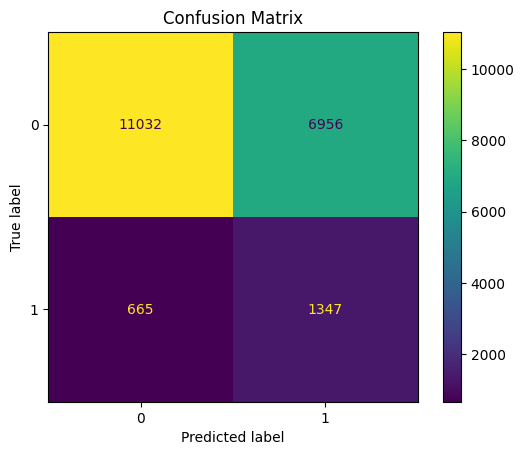

In [65]:
ConfusionMatrixDisplay.from_estimator(best_lr, X_test_scaled, y_test)

plt.title("Confusion Matrix")
plt.show()

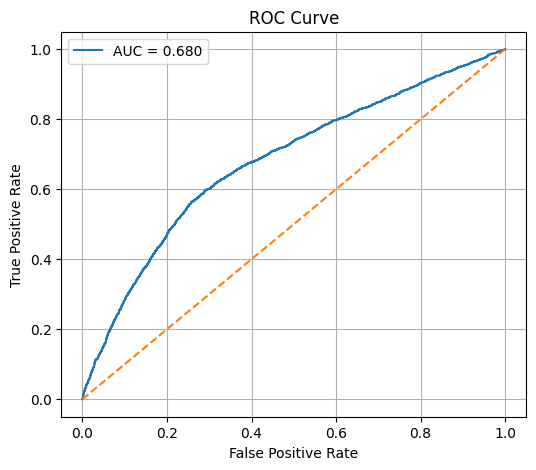

ROC-AUC Score: 0.6795764770947365


In [66]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

The final model is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.  and a Confusion Matrix to visualize the classification results.



## 8. Conclusion
Summarize which model performed best, what your results mean, and what you would improve with more time.

In this project, we built a machine learning model to predict the risk of students having depression.
We explore and clean the dataset, also use Feature scaling and PCA to improve the data before training the models.

tried five machine learning models, which are (Logistic Regression, Decision Tree, Random Forest, KNN, and SVM) with their default parameter, they got high accuracy, but they did not detect students with depression well because the dataset was imbalanced. also tried them with PCA and without PCA.

To improve the results, I tried Logistic Regression using class_weight='balanced' and GridSearchCV. This helped the model identify more students with depression.

The Logistic Regression model achieved:
Accuracy: 61.90%
Precision: 16.22%
Recall: 66.95%
F1-score: 26.12%
ROC-AUC: 67.95%

With the highest Recall (66.95%), this makes it more effective at identifying students with depression.

In the future, I will improve the model's performance by adding more data, addressing the imbalanced data, and tuning the model's hyperparameters to find the best one.

##for call the models in Streamlit app

In [67]:
#Saving all Models
import os
import joblib


joblib.dump(best_lr, "Logistic_model.pkl")
joblib.dump(best_dt, "decision_tree_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_names.pkl")



print("Saved successfully")
print("Number of cloumns:", len(X.columns))

Saved successfully
Number of cloumns: 14
